In [1]:
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import splrep, splev
from scipy.spatial.distance import mahalanobis
from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.nonparametric.smoothers_lowess import lowess


def adjust_the_line(red_cell, green_cell):
    new_red_value = interplote_data(red_cell, 1000)
    average = lowess_smooth(new_red_value)

    baseline_average = find_baseline(average)
    mini_crop, max_crop = find_crops(average, baseline_average)
    data_new = average[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new))
    y = data_new
    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_red_y = splev(new_x, spl)

    new_green_value = interplote_data(green_cell, 1000)
    smooth_green = lowess_smooth(new_green_value)
    data_new_green = smooth_green[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new_green))
    y = data_new_green
    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_green_y = splev(new_x, spl)

    return new_red_y, new_green_y


def interplote_data(list, num):
    x = np.linspace(0, 1, len(list))
    spl = splrep(x, list)
    new_x = np.linspace(0, 1, num)
    new_value = splev(new_x, spl)
    return new_value


def find_baseline(data):
    n = len(data)

    start_index = int(n * 0.30)
    end_index = int(n * 0.70)
    middle_40_percent = data[start_index:end_index]
    min_value = min(middle_40_percent)
    min_indices_relative = [
        i for i, value in enumerate(middle_40_percent)
        if value == min_value
    ]
    min_indices_absolute = start_index + min_indices_relative[0]

    baseline_value = data[
        min_indices_absolute - int(n * 0.005):
        min_indices_absolute + int(n * 0.005)
    ]
    baseline_average = np.mean(baseline_value)
    return baseline_average


def lowess_smooth(data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:, 1]


def interpolate_data_b(x, y, num):
    spl = splrep(x, y)
    new_x = np.linspace(min(x), max(x), num)
    new_value = splev(new_x, spl)
    return new_value


def half_data(list, num):
    num_r = math.ceil(num / 2)
    front_half = list[:num_r]
    back_half = list[num_r:]
    front_half_reversed = front_half[::-1]

    return front_half_reversed, back_half


def ave_center_data(data):
    n = len(data)

    start = int(n * 0.495)
    end = int(n * 0.595)
    middle_1_percent = data[start:end]

    baseline = sum(middle_1_percent) / len(middle_1_percent)

    return baseline


def fraction(list):
    total_sum = sum(list)
    cumulative_sum = []
    current_sum = 0

    for value in list:
        current_sum += value
        cumulative_sum.append(current_sum)

    cumulative_weights = [
        cs / total_sum
        for cs in cumulative_sum
    ]
    return cumulative_weights


def fig_4_create(new_red, new_green):
    front_green, back_green = half_data(new_green, len(new_green))

    x_front = fraction(front_green)
    x_back = fraction(back_green)

    baseline = ave_center_data(new_red)
    front_red, back_red = half_data(new_red, len(new_red))

    front_red_b = [
        (x / baseline) - 1
        for x in front_red
    ]
    back_red_b = [
        (x / baseline) - 1
        for x in back_red
    ]

    intensity_front = interpolate_data_b(x_front, front_red_b, 1000)
    intensity_back = interpolate_data_b(x_back, back_red_b, 1000)

    return intensity_front, intensity_back


In [2]:
def find_crops(data, target_value):
    data_as_int = [int(float(x)) for x in data]
    matching_indices = [
        i for i, value in enumerate(data_as_int)
        if value < target_value * 0.9
    ]
    mini_crop = 0
    max_crop = len(data)

    if 0 in matching_indices:
        i = 0
        while i in range(0, len(matching_indices)):
            if 0 < (matching_indices[i + 1] - matching_indices[i]) <= 2:
                mini_crop = matching_indices[i + 1]
                i += 1
            else:
                break

    reverse_matching_indices = matching_indices[::-1]

    if (len(data) - 1) in reverse_matching_indices:
        i = 0
        while i in range(0, len(reverse_matching_indices)):
            if 0 < (
                reverse_matching_indices[i]
                - reverse_matching_indices[i + 1]
            ) <= 2:
                max_crop = reverse_matching_indices[i + 1]
                i += 1
            else:
                break

    return mini_crop, max_crop


def allinfunction(folder_path, cell_infomration_path):
    csv_files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".csv")
    ]
    cell_infomation_df = pd.read_csv(cell_infomration_path)
    ps6_intensity = cell_infomation_df.iloc[:, 0].tolist()

    fig_5_max = []
    ps6_intensities = []

    for i in range(len(csv_files)):
        try:
            df = pd.read_csv(
                os.path.join(folder_path, csv_files[i])
            )
            red_cell = df.iloc[:, 2].tolist()

            if np.mean(red_cell) <= 150:
                continue

            green_cell = df.iloc[:, 1].tolist()

            new_green_1, new_red_1 = adjust_the_line(
                green_cell,
                red_cell
            )

            new_green = [
                value - 100
                for value in new_green_1
            ]
            new_red = [
                value - 100
                for value in new_red_1
            ]

            intensity_front_4, intensity_back_4 = fig_4_create(
                new_red,
                new_green
            )

            averaged_list = [
                (a + b) / 2
                for a, b in zip(
                    intensity_front_4,
                    intensity_back_4
                )
            ]

            fig_5_max.append(
                np.mean(averaged_list[980:])
            )
            ps6_intensities.append(
                ps6_intensity[i]
            )

        except:
            continue

    return fig_5_max, ps6_intensities


In [ ]:
folder_path = r"timed fixation Fig3\t8 control"
cell_path = r"timed fixation Fig3\t8 control cell ps6 intensity.csv"

fig_5_max_5, ps6_intensities_5 = allinfunction(
    folder_path,
    cell_path
)


In [ ]:
folder_path = r"timed fixation Fig3\t8 drug"
cell_path = r"timed fixation Fig3\t8 drug cell ps6 intensity.csv"

fig_5_max_5_drug, ps6_intensities_5_drug = allinfunction(
    folder_path,
    cell_path
)


In [5]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

ps6_drug = np.asarray(
    ps6_intensities_5_drug,
    dtype=float
)
ps6_ctrl = np.asarray(
    ps6_intensities_5,
    dtype=float
)

ps6_drug = ps6_drug[np.isfinite(ps6_drug)]
ps6_ctrl = ps6_ctrl[np.isfinite(ps6_ctrl)]

X_drug = ps6_drug.reshape(-1, 1)
X_ctrl = ps6_ctrl.reshape(-1, 1)

drug_mean = np.mean(X_drug, axis=0)

drug_cov = np.cov(X_drug, rowvar=False)
drug_cov = np.atleast_2d(drug_cov)
drug_cov += np.eye(drug_cov.shape[0]) * 1e-6

inv_cov = np.linalg.inv(drug_cov)

dist_drug_to_drug = np.array([
    mahalanobis(x, drug_mean, inv_cov)
    for x in X_drug
])

dist_ctrl_to_drug = np.array([
    mahalanobis(x, drug_mean, inv_cov)
    for x in X_ctrl
])

base_cutoff = np.percentile(
    dist_drug_to_drug,
    95
)

print("Drug mean:", np.mean(ps6_drug))
print("Drug std:", np.std(ps6_drug, ddof=1))
print("Base 95% Mahalanobis cutoff:", base_cutoff)
print(
    "Max control-to-drug Mahalanobis distance:",
    np.max(dist_ctrl_to_drug)
)


Drug mean: 113.60827272727273
Drug std: 2.623682221281457
Base 95% Mahalanobis cutoff: 1.330494666113054
Max control-to-drug Mahalanobis distance: 114.97150947459738


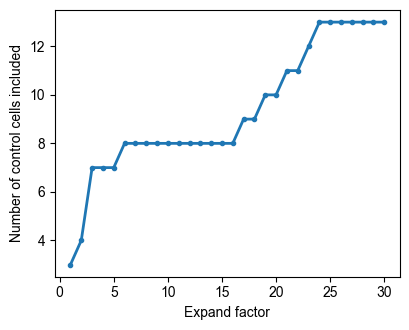

In [6]:
expand_factors = np.arange(1, 31, 1)

summary = []

for factor in expand_factors:
    cutoff = base_cutoff * factor
    drug_like_mask = dist_ctrl_to_drug <= cutoff

    n_selected = np.sum(drug_like_mask)
    fraction_selected = n_selected / len(ps6_ctrl)

    summary.append({
        "expand_factor": factor,
        "cutoff": cutoff,
        "n_selected": n_selected,
        "fraction_selected": fraction_selected
    })

summary_df = pd.DataFrame(summary)

summary_df.head()

plt.figure(figsize=(4.2, 3.4))

plt.plot(
    summary_df["expand_factor"],
    summary_df["n_selected"],
    marker="o",
    markersize=3,
    linewidth=2
)

plt.xlabel("Expand factor")
plt.ylabel("Number of control cells included")

plt.tight_layout()
plt.show()


In [7]:
ps6_drug_raw = np.asarray(
    ps6_intensities_5_drug,
    dtype=float
)
ps6_ctrl_raw = np.asarray(
    ps6_intensities_5,
    dtype=float
)
fig_ctrl_raw = np.asarray(
    fig_5_max_5,
    dtype=float
)

valid_drug = np.isfinite(ps6_drug_raw)
ps6_drug = ps6_drug_raw[valid_drug]

valid_ctrl = (
    np.isfinite(ps6_ctrl_raw)
    & np.isfinite(fig_ctrl_raw)
)

ps6_ctrl = ps6_ctrl_raw[valid_ctrl]
fig_ctrl = fig_ctrl_raw[valid_ctrl]

X_drug = ps6_drug.reshape(-1, 1)
X_ctrl = ps6_ctrl.reshape(-1, 1)

drug_mean = np.mean(X_drug, axis=0)
drug_cov = np.cov(X_drug, rowvar=False)
drug_cov = np.atleast_2d(drug_cov)
drug_cov += np.eye(drug_cov.shape[0]) * 1e-6

inv_cov = np.linalg.inv(drug_cov)

dist_drug_to_drug = np.array([
    mahalanobis(x, drug_mean, inv_cov)
    for x in X_drug
])

dist_ctrl_to_drug = np.array([
    mahalanobis(x, drug_mean, inv_cov)
    for x in X_ctrl
])

base_cutoff = np.percentile(
    dist_drug_to_drug,
    95
)

expansion_factor = 6
distance_cutoff = base_cutoff * expansion_factor

drug_like_ctrl_mask = (
    dist_ctrl_to_drug
    <= distance_cutoff
)

ps6_ctrl_drug_like = ps6_ctrl[
    drug_like_ctrl_mask
]
ps6_ctrl_other = ps6_ctrl[
    ~drug_like_ctrl_mask
]

fig_ctrl_drug_like = fig_ctrl[
    drug_like_ctrl_mask
]
fig_ctrl_other = fig_ctrl[
    ~drug_like_ctrl_mask
]

print("Drug pS6 mean:", np.mean(ps6_drug))
print(
    "Drug pS6 std:",
    np.std(ps6_drug, ddof=1)
)
print(
    "Base 95% Mahalanobis cutoff:",
    base_cutoff
)
print("Expansion factor:", expansion_factor)
print(
    "Expanded Mahalanobis cutoff:",
    distance_cutoff
)

print("\nDrug-like control pS6 values:")
print(ps6_ctrl_drug_like)
print("n =", len(ps6_ctrl_drug_like))

print("\nNon-drug-like control pS6 values:")
print(ps6_ctrl_other)
print("n =", len(ps6_ctrl_other))

print(
    "\nCorresponding fig_5_max_5 values "
    "in drug-like control:"
)
print(fig_ctrl_drug_like)

print(
    "\nCorresponding fig_5_max_5 values "
    "in non-drug-like control:"
)
print(fig_ctrl_other)


Drug pS6 mean: 113.60827272727273
Drug pS6 std: 2.623682221281457
Base 95% Mahalanobis cutoff: 1.330494666113054
Expansion factor: 6
Expanded Mahalanobis cutoff: 7.982967996678323

Drug-like control pS6 values:
[121.409 114.235 131.177 116.624 123.021 115.276 123.328 119.152]
n = 8

Non-drug-like control pS6 values:
[355.685 269.851 346.149 170.668 177.061 333.833 185.325 247.956 256.678
 263.127 195.687 322.937 415.257 193.317 255.924]
n = 15

Corresponding fig_5_max_5 values in drug-like control:
[-0.03419483 -0.03333084  0.26168761  1.74495982  0.45720192  1.33776092
 -0.03321491  0.09635591]

Corresponding fig_5_max_5 values in non-drug-like control:
[-0.12930128 -0.3989013  -0.2875327   0.14238967 -0.05403578 -0.27262436
 -0.31635145 -0.33183216  0.0657814  -0.30342047  0.12399358 -0.16501416
  0.02597357 -0.26991503 -0.03703541]


In [ ]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def plot_two_groups_symlog(
    group1,
    group2,
    labels=("Low anti-pS6", "High anti-pS6"),
    ylabel="Recorder signal change from baseline",
    linthresh=0.1,
    figsize=(3, 3.5),
    bar_colors=("white", "#9ecf9e"),
    dot_colors=("gray", "#397747"),
    bar_width=0.65,
    jitter_width=0.1,
    point_size=20,
):
    g1 = np.asarray(group1, dtype=float)
    g2 = np.asarray(group2, dtype=float)

    g1 = g1[np.isfinite(g1)]
    g2 = g2[np.isfinite(g2)]

    data = [g1, g2]
    xpos = [1, 2]

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=300
    )

    medians = [
        np.median(g)
        for g in data
    ]
    q1_values = [
        np.percentile(g, 25)
        for g in data
    ]
    q3_values = [
        np.percentile(g, 75)
        for g in data
    ]

    ax.bar(
        xpos,
        medians,
        width=bar_width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1,
        zorder=2,
    )

    rng = np.random.default_rng(1)

    for i, g in enumerate(data):
        jitter = rng.normal(
            loc=0,
            scale=jitter_width,
            size=len(g),
        )

        ax.scatter(
            np.full(len(g), xpos[i]) + jitter,
            g,
            s=point_size,
            color=dot_colors[i],
            alpha=0.9,
            edgecolors="none",
            zorder=4,
        )

    for i, (median, q1, q3) in enumerate(
        zip(medians, q1_values, q3_values)
    ):
        ax.errorbar(
            xpos[i],
            median,
            yerr=[
                [median - q1],
                [q3 - median],
            ],
            fmt="_",
            color="black",
            capsize=10,
            elinewidth=2,
            capthick=2,
            markersize=18,
            markeredgewidth=2,
            zorder=5,
        )

    stat, p = mannwhitneyu(
        g1,
        g2,
        alternative="two-sided",
    )

    if p < 0.0001:
        star = "****"
    elif p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = "ns"

    ax.set_yscale(
        "symlog",
        linthresh=linthresh,
    )

    ax.axhline(
        0,
        color="black",
        linestyle=(0, (1, 4)),
        linewidth=1.5,
        zorder=1,
    )

    all_y = np.concatenate(data)
    y_max = np.nanmax(all_y)

    y_bar = y_max * 1.35 if y_max > 0 else 0.3
    h = y_bar * 0.12

    ax.plot(
        [xpos[0], xpos[0], xpos[1], xpos[1]],
        [y_bar, y_bar + h, y_bar + h, y_bar],
        color="black",
        linewidth=1.5,
        clip_on=False,
        zorder=6,
    )

    ax.text(
        np.mean(xpos),
        y_bar + h * 1.15,
        star,
        ha="center",
        va="bottom",
        fontsize=18,
        fontweight="bold",
    )

    ax.set_xticks(xpos)
    ax.set_xticklabels(
        labels,
        rotation=35,
        ha="right",
        fontsize=12,
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
        length=4,
        width=1.2,
        direction="out",
        bottom=True,
        left=True,
    )

    ax.set_xlim(0.4, 2.6)

    plt.tight_layout()

    print(
        f"Mann–Whitney U test: "
        f"U = {stat:.3f}, p = {p:.4g}"
    )

    return fig, ax


fig, ax = plot_two_groups_symlog(
    fig_ctrl_drug_like,
    fig_ctrl_other,
    labels=("Low anti-pS6", "High anti-pS6"),
    ylabel="Recorder signal change from baseline",
    linthresh=0.1,
    bar_colors=("white", "#c5e7c5"),
    dot_colors=("gray", "#397747"),
    bar_width=0.45,
    jitter_width=0.1,
    point_size=20,
)

plt.show()


In [9]:
u_stat, p_mwu = mannwhitneyu(
    fig_ctrl_drug_like,
    fig_ctrl_other,
    alternative="two-sided"
)

print("\nMann-Whitney U test:")
print("U =", u_stat)
print("p =", p_mwu)

t_stat, p_ttest = ttest_ind(
    fig_ctrl_drug_like,
    fig_ctrl_other,
    equal_var=False
)

print("\nWelch's t-test:")
print("t =", t_stat)
print("p =", p_ttest)



Mann-Whitney U test:
U = 106.0
p = 0.0018885856818283795

Welch's t-test:
t = 2.5076236812037176
p = 0.038312078151263786
